In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [13]:
conv = {
    2: lambda x: int(x[:-1]),
    5: lambda x: float(x)
}

In [18]:
oldfinedata = np.loadtxt('./CIS_LiH_6-31g_maes.txt',usecols=(2,5),converters=conv)

In [36]:
olddelays = np.array(list(map(lambda x : int(x), oldfinedata[:,0])), dtype=np.int16)

In [21]:
filedelays = np.arange(5100,9900,100,dtype=np.int16)

In [26]:
newfinedata = []
for delay in filedelays:
    fname = './cis_lih_6-31g/cis_lih_6-31g_0.001000_'+str(delay)+'.txt'
    newfinedata.append(np.loadtxt(fname))

newfinedata = np.array(newfinedata)

In [37]:
finemae={}
finemae['delayrange']=np.concatenate([olddelays,filedelays])
finemae['dt']=0.001
finemae['maes']=np.concatenate([oldfinedata[:,1], newfinedata])

In [38]:
coarsemae = np.load('maes_dt_0.01_cis_lih_6-31g.npz')

In [39]:
list(coarsemae.keys())

['maes', 'delayrange', 'dt']

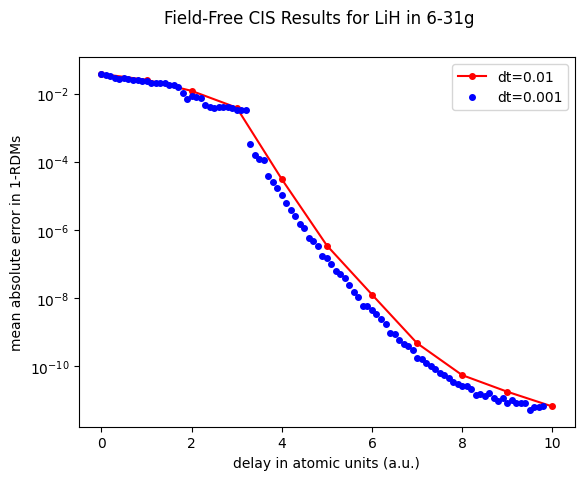

In [40]:
plt.semilogy(coarsemae['dt']*coarsemae['delayrange'],coarsemae['maes'],label='dt=0.01',
            marker='o', markersize=4, color='red')
plt.semilogy(finemae['dt']*finemae['delayrange'],finemae['maes'],label='dt=0.001',
            linestyle='none', marker='o', markersize=4, color='blue')
plt.xlabel('delay in atomic units (a.u.)')
plt.ylabel('mean absolute error in 1-RDMs')
plt.suptitle('Field-Free CIS Results for LiH in 6-31g')
plt.legend()
plt.show()